In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV file load karo
df = pd.read_csv("books_data_full.csv")

# Pehli 5 rows dekho
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'books_data_full.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV file load karo
df = pd.read_csv("books_data_full.csv")

# Pehli 5 rows dekho
df.head()

ModuleNotFoundError: No module named 'seaborn'

In [1]:
import sys
!{sys.executable} -m pip install seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
print(os.getcwd())

c:\Users\Hashu\Desktop\CodeAlpha_WebScraping\CodeAlpha_EDA


In [4]:
import os
print(os.getcwd())

c:\Users\Hashu\Desktop\CodeAlpha_WebScraping\CodeAlpha_EDA


In [6]:
df = pd.read_csv(r"C:\Users\Hashu\Desktop\CodeAlpha_WebScraping\books_data_full.csv")

In [7]:
print("Shape:", df.shape)
df.info()

Shape: (1000, 3)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Title         1000 non-null   str  
 1   Price         1000 non-null   str  
 2   Availability  1000 non-null   str  
dtypes: str(3)
memory usage: 23.6 KB


In [8]:
df.describe()

,Title,Price,Availability
count,1000,1000,1000
unique,999,903,1
top,The Star-Touched Queen,£44.18,In stock
freq,2,3,1000


In [9]:
df['Price_Numeric'] = df['Price'].str.replace('£', '').astype(float)
df[['Price', 'Price_Numeric']].head()

,Price,Price_Numeric
0,£51.77,51.77
1,£53.74,53.74
2,£50.10,50.10
3,£47.82,47.82
4,£54.23,54.23


In [10]:
df['Price_Numeric'].describe()

count    1000.00000
mean       35.07035
std        14.44669
min        10.00000
25%        22.10750
50%        35.98000
75%        47.45750
max        59.99000
Name: Price_Numeric, dtype: float64

In [13]:
cheapest = df.loc[df['Price_Numeric'].idxmin()]
most_expensive = df.loc[df['Price_Numeric'].idxmax()]

print("cheap book:\n", cheapest)
print("\nExpensive book:\n", most_expensive)

cheap book:
 Title            An Abundance of Katherines
Price                                £10.00
Availability                       In stock
Price_Numeric                          10.0
Name: 638, dtype: object

Expensive book:
 Title            The Perfect Play (Play by Play #1)
Price                                        £59.99
Availability                               In stock
Price_Numeric                                 59.99
Name: 648, dtype: object


In [14]:
df['Availability'].value_counts()

Availability
In stock    1000
Name: count, dtype: int64

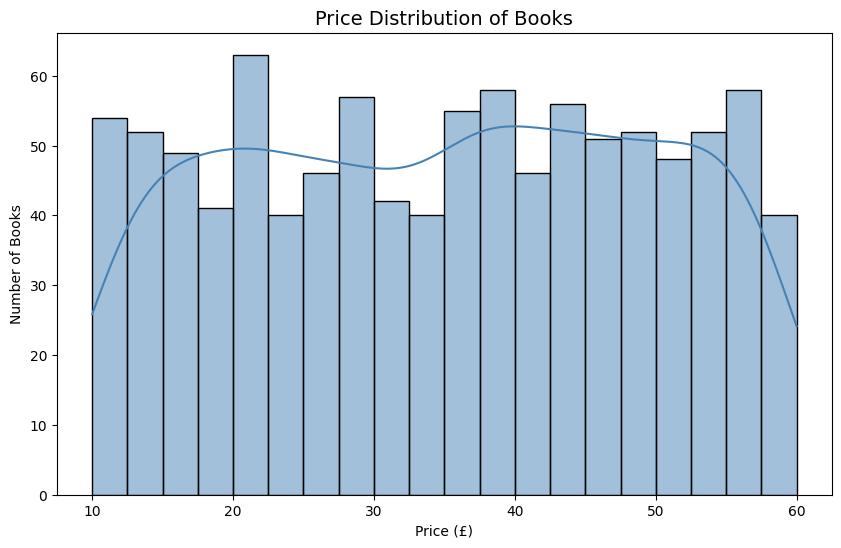

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_Numeric'], bins=20, kde=True, color='steelblue')
plt.title('Price Distribution of Books', fontsize=14)
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()

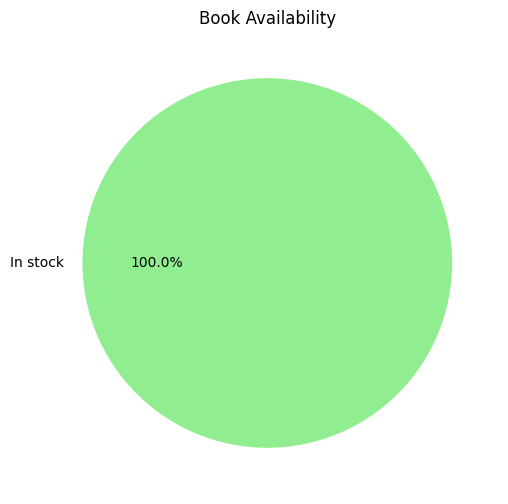

In [16]:
availability_counts = df['Availability'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(availability_counts, labels=availability_counts.index, autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Book Availability')
plt.show()

C:\Users\Hashu\AppData\Local\Temp\ipykernel_12124\2198465140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='Title', x='Price_Numeric', palette='viridis')


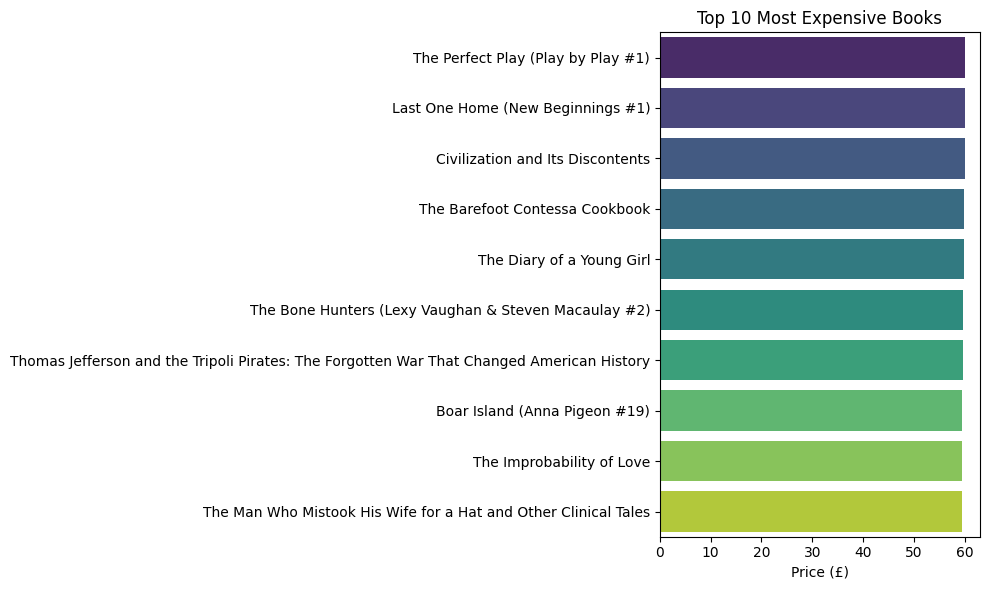

In [17]:
top_10 = df.nlargest(10, 'Price_Numeric')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, y='Title', x='Price_Numeric', palette='viridis')
plt.title('Top 10 Most Expensive Books')
plt.xlabel('Price (£)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 📊 Key Insights from EDA

- Dataset mein total **1000 books** hain, koi missing values nahi.
- Book prices **£10.00 se £59.99** tak range karte hain.
- Sabse sasti book: **"An Abundance of Katherines"** (£10.00)
- Sabse mehngi book: **"The Perfect Play (Play by Play #1)"** (£59.99)
- Prices ka distribution fairly **uniform/even** hai — koi ek price range dominant nahi hai.
- **100% books "In stock"** hain — is dataset mein koi book out-of-stock nahi hai.